# EMA 21/13/8 Crypto Strategy — Bybit Live Data (Migrated from MT5)

> **Migration note**: This notebook was migrated from `03_strategy03_crypto.ipynb` (MT5/CSV-cache version).
> The execution layer changed from **local CSV cache** to **live Bybit REST API** (`pybit` via `market.data_fetcher`).
> Strategy logic is **byte-identical** to the MT5 version — EMA calculations, trend rules, signal geometry, and risk formula are unchanged.

## What changed vs. `03_strategy03_crypto.ipynb`
| Original (CSV cache) | This notebook (Bybit live) |
|---------------------|--------------------------|
| Reads `./data/<symbol>/<tf>/ohlcv.csv` | Fetches live from Bybit REST |
| Needs pre-cached data | Always up-to-date |
| Offline, reproducible | Online, reflects current market |
| Any symbol in cache | Any Bybit Linear symbol |

## What stayed the same
- EMA 8/13/21 calculation (`strategy.crypto_core.add_emas`)
- H1 trend rules (`strategy.crypto_core.merge_h1_trend_onto_m5`)
- Signal generation (`strategy.setup.list_setup_signals`)
- Backtest engine (`strategy.backtest.run_backtest`)
- Risk formula (`risk_cash = balance × risk_per_trade`)
- Result output format (`./results/strategy03_crypto/...`)


In [43]:
# SECTION 1 — Imports and parameters
import warnings
warnings.filterwarnings("ignore")

import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# Resolve project root (notebooks/ -> parent)
_ROOT = Path.cwd().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

# Load .env
try:
    from dotenv import load_dotenv
    _env = _ROOT / ".env"
    if _env.exists():
        load_dotenv(_env)
except ImportError:
    pass

from strategy.crypto_core import EMA_FAST, EMA_MID, EMA_SLOW, default_crypto_tick

# === User parameters ===
SYMBOL = "XRPUSDT"
# Other Bybit symbols: "ETHUSDT", "SOLUSDT", "XRPUSDT", "BNBUSDT", "ADAUSDT"
TF_ENTRY = "M5"
TF_TREND = "H1"

LOOKBACK_BARS      = 5
PENDING_OFFSET_TICKS = 3.0
PENDING_EXPIRY_MIN = 60
RR                 = 1.0
PIP_SIZE           = default_crypto_tick(SYMBOL)
PENDING_OFFSET_PIPS = float(PENDING_OFFSET_TICKS)

START_BALANCE  = 10000.0
RISK_PER_TRADE = 0.01

BARS_M5 = 8000   # last N closed M5 candles to backtest over
BARS_H1 = 2000   # H1 bars for trend context

CATEGORY = "linear"
TESTNET  = os.getenv("BYBIT_TESTNET", "false").lower() == "true"

print(f"Symbol={SYMBOL}, Trend={TF_TREND}, Entry={TF_ENTRY}")
print(f"PIP_SIZE={PIP_SIZE}, offset_ticks={PENDING_OFFSET_TICKS}")
print(f"Testnet={TESTNET}")


Symbol=XRPUSDT, Trend=H1, Entry=M5
PIP_SIZE=0.0001, offset_ticks=3.0
Testnet=False


In [44]:
# SECTION 2 — Load OHLCV from local cache (./data/SYMBOL/TIMEFRAME/ohlcv.csv)
DATA_DIR = _ROOT / "notebooks" / "data"


def _load_csv(symbol: str, tf: str, limit: int) -> pd.DataFrame:
    csv_path = DATA_DIR / symbol / tf / "ohlcv.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Cache file not found: {csv_path}\n"
            f"Run 00_data_fetching_bybit.ipynb first to populate the cache."
        )
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    df = df.sort_index()
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)
    df = df[["open", "high", "low", "close", "volume"]]
    if limit and len(df) > limit:
        df = df.iloc[-limit:]
    return df


print(f"Loading {TF_ENTRY} candles for {SYMBOL} from cache...")
m5 = _load_csv(SYMBOL, TF_ENTRY, limit=BARS_M5)
print(f"  -> {len(m5):,} rows, {m5.index[0]} to {m5.index[-1]}")

print(f"Loading {TF_TREND} candles for {SYMBOL} from cache...")
h1 = _load_csv(SYMBOL, TF_TREND, limit=BARS_H1)
print(f"  -> {len(h1):,} rows, {h1.index[0]} to {h1.index[-1]}")

display(m5.tail(3))
display(h1.tail(3))


Loading M5 candles for XRPUSDT from cache...
  -> 8,000 rows, 2026-04-14 17:20:00+00:00 to 2026-05-12 11:55:00+00:00
Loading H1 candles for XRPUSDT from cache...
  -> 2,000 rows, 2026-02-18 04:00:00+00:00 to 2026-05-12 11:00:00+00:00


,open,high,low,close,volume
time,,,,,
2026-05-12 11:45:00+00:00,1.4480,1.4486,1.4467,1.4478,367256.7
2026-05-12 11:50:00+00:00,1.4478,1.4488,1.4472,1.4483,691592.3
2026-05-12 11:55:00+00:00,1.4483,1.4488,1.4479,1.4483,360607.0


,open,high,low,close,volume
time,,,,,
2026-05-12 09:00:00+00:00,1.4644,1.4644,1.4536,1.4549,11601271.4
2026-05-12 10:00:00+00:00,1.4549,1.4574,1.4458,1.4490,16881008.2
2026-05-12 11:00:00+00:00,1.4490,1.4513,1.4432,1.4483,9743675.0


In [45]:
# SECTION 3 — Build EMA 8/13/21 on both timeframes
from strategy.crypto_core import add_emas

m5 = add_emas(m5)
h1 = add_emas(h1)

print("EMA columns added.")
display(h1[[f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))

EMA columns added.


,ema_8,ema_13,ema_21
time,,,
2026-05-12 07:00:00+00:00,1.463451,1.464836,1.464518
2026-05-12 08:00:00+00:00,1.463662,1.464773,1.464507
2026-05-12 09:00:00+00:00,1.461715,1.463363,1.463634
2026-05-12 10:00:00+00:00,1.458889,1.461311,1.462303
2026-05-12 11:00:00+00:00,1.456536,1.459452,1.461030


In [46]:
# SECTION 4 — Merge H1 trend onto M5 (no lookahead)
from strategy.crypto_core import merge_h1_trend_onto_m5

m5_ctx = merge_h1_trend_onto_m5(m5, h1)

print(m5_ctx["trend"].value_counts(dropna=False))
display(m5_ctx[["close", "trend"]].tail(8))


trend
bull    3464
bear    2580
flat    1956
Name: count, dtype: int64


,close,trend
time,,
2026-05-12 11:20:00+00:00,1.4440,bear
2026-05-12 11:25:00+00:00,1.4457,bear
2026-05-12 11:30:00+00:00,1.4472,bear
2026-05-12 11:35:00+00:00,1.4471,bear
2026-05-12 11:40:00+00:00,1.4480,bear
2026-05-12 11:45:00+00:00,1.4478,bear
2026-05-12 11:50:00+00:00,1.4483,bear
2026-05-12 11:55:00+00:00,1.4483,bear


In [47]:
# SECTION 5 — Run backtest
from strategy.backtest import run_backtest

trades_df, equity_curve = run_backtest(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)
print(f"Total trades: {len(trades_df)}")
display(trades_df.head(10))


Total trades: 161


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result
0,2026-04-15 02:30:00+00:00,2026-04-15 07:15:00+00:00,sell,1.3581,1.3646,1.3516,1.3516,15384.615385,100.000000,10100.000000,win
1,2026-04-15 14:15:00+00:00,2026-04-15 14:25:00+00:00,buy,1.3672,1.3605,1.3739,1.3739,15074.626866,101.000000,10201.000000,win
2,2026-04-15 14:50:00+00:00,2026-04-15 19:25:00+00:00,buy,1.3756,1.3632,1.3880,1.3880,8226.612903,102.010000,10303.010000,win
3,2026-04-15 19:35:00+00:00,2026-04-15 19:40:00+00:00,buy,1.3891,1.3844,1.3938,1.3938,21921.297872,103.030100,10406.040100,win
4,2026-04-15 22:00:00+00:00,2026-04-15 22:05:00+00:00,buy,1.3885,1.3819,1.3951,1.3951,15766.727424,104.060401,10510.100501,win
5,2026-04-16 00:30:00+00:00,2026-04-16 01:15:00+00:00,buy,1.3929,1.3877,1.3981,1.3981,20211.731733,105.101005,10615.201506,win
6,2026-04-16 01:25:00+00:00,2026-04-16 02:40:00+00:00,buy,1.3986,1.3894,1.4078,1.4078,11538.262507,106.152015,10721.353521,win
7,2026-04-16 03:00:00+00:00,2026-04-16 12:10:00+00:00,buy,1.4094,1.3959,1.4229,1.4229,7941.743349,107.213535,10828.567056,win
8,2026-04-16 13:15:00+00:00,2026-04-16 13:50:00+00:00,buy,1.4232,1.4061,1.4403,1.4061,6332.495355,-108.285671,10720.281386,loss
9,2026-04-16 15:05:00+00:00,2026-04-16 15:35:00+00:00,buy,1.4125,1.3992,1.4258,1.4258,8060.361944,107.202814,10827.484200,win


In [48]:
# SECTION 5b — Entry signals vs actual fills
import importlib
import strategy.backtest as _backtest_mod
importlib.reload(_backtest_mod)
from strategy.setup import list_setup_signals, list_trade_entries

entry_signals_df = list_setup_signals(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
)
entry_fills_df = list_trade_entries(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)

print(f"Signals (pending-setup bars): {len(entry_signals_df)}")
print(f"Fills   (pending triggered) : {len(entry_fills_df)}")
display(entry_signals_df.head(10))
display(entry_fills_df.head(10))

# Save signals
_out = Path("./results") / "strategy03_crypto" / SYMBOL / TF_ENTRY
_out.mkdir(parents=True, exist_ok=True)
entry_signals_df.to_csv(_out / "entry_signals.csv", index=False)
entry_fills_df.to_csv(_out / "entry_fills.csv", index=False)
print(f"Saved signals -> {_out}")


Signals (pending-setup bars): 6039
Fills   (pending triggered) : 161


,signal_bar_index,signal_bar_time,trend,side,entry,sl,tp,qty
0,5,2026-04-14 17:45:00+00:00,bull,buy,1.3737,1.3640,1.3834,10309.278351
1,6,2026-04-14 17:50:00+00:00,bull,buy,1.3737,1.3640,1.3834,10309.278351
2,7,2026-04-14 17:55:00+00:00,bull,buy,1.3714,1.3640,1.3788,13513.513514
3,104,2026-04-15 02:00:00+00:00,bear,sell,1.3581,1.3646,1.3516,15384.615385
4,105,2026-04-15 02:05:00+00:00,bear,sell,1.3598,1.3646,1.3550,20833.333333
5,106,2026-04-15 02:10:00+00:00,bear,sell,1.3597,1.3646,1.3548,20408.163265
6,107,2026-04-15 02:15:00+00:00,bear,sell,1.3597,1.3646,1.3548,20408.163265
7,108,2026-04-15 02:20:00+00:00,bear,sell,1.3597,1.3640,1.3554,23255.813953
8,109,2026-04-15 02:25:00+00:00,bear,sell,1.3597,1.3640,1.3554,23255.813953
9,110,2026-04-15 02:30:00+00:00,bear,sell,1.3583,1.3632,1.3534,20408.163265


,signal_bar_time,signal_bar_index,entry_time,entry_bar_index,side,entry,sl,tp,qty
0,2026-04-15 02:00:00+00:00,104,2026-04-15 02:30:00+00:00,110,sell,1.3581,1.3646,1.3516,15384.615385
1,2026-04-15 14:00:00+00:00,248,2026-04-15 14:15:00+00:00,251,buy,1.3672,1.3605,1.3739,15074.626866
2,2026-04-15 14:30:00+00:00,254,2026-04-15 14:50:00+00:00,258,buy,1.3756,1.3632,1.3880,8226.612903
3,2026-04-15 19:30:00+00:00,314,2026-04-15 19:35:00+00:00,315,buy,1.3891,1.3844,1.3938,21921.297872
4,2026-04-15 21:55:00+00:00,343,2026-04-15 22:00:00+00:00,344,buy,1.3885,1.3819,1.3951,15766.727424
5,2026-04-16 00:20:00+00:00,372,2026-04-16 00:30:00+00:00,374,buy,1.3929,1.3877,1.3981,20211.731733
6,2026-04-16 01:20:00+00:00,384,2026-04-16 01:25:00+00:00,385,buy,1.3986,1.3894,1.4078,11538.262507
7,2026-04-16 02:45:00+00:00,401,2026-04-16 03:00:00+00:00,404,buy,1.4094,1.3959,1.4229,7941.743349
8,2026-04-16 12:15:00+00:00,515,2026-04-16 13:15:00+00:00,527,buy,1.4232,1.4061,1.4403,6332.495355
9,2026-04-16 15:00:00+00:00,548,2026-04-16 15:05:00+00:00,549,buy,1.4125,1.3992,1.4258,8060.361944


Saved signals -> results\strategy03_crypto\XRPUSDT\M5


In [49]:
# SECTION 6 — Metrics
def max_drawdown_pct(equity: pd.Series | None) -> float:
    if equity is None or len(equity) < 2:
        return 0.0
    eq   = pd.Series(equity).astype(float).dropna()
    peak = eq.cummax()
    dd   = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize_results(trades: pd.DataFrame, start_balance: float, equity=None) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{"trades": 0, "win_rate_%": 0.0, "net_pnl": 0.0,
                               "profit_factor": 0.0, "max_drawdown_%": round(max_drawdown_pct(equity), 2),
                               "start_balance": start_balance, "end_balance": start_balance, "return_%": 0.0}])
    wins   = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]
    gp     = wins.sum() if not wins.empty else 0.0
    gl     = abs(losses.sum()) if not losses.empty else 0.0
    pf     = gp / gl if gl > 0 else np.nan
    end_b  = float(trades["balance_after"].iloc[-1])
    return pd.DataFrame([{
        "trades":          int(len(trades)),
        "win_rate_%":      round((trades["pnl"] > 0).mean() * 100, 2),
        "net_pnl":         round(trades["pnl"].sum(), 2),
        "avg_pnl":         round(trades["pnl"].mean(), 2),
        "profit_factor":   round(float(pf), 3) if pd.notna(pf) else np.nan,
        "max_drawdown_%":  round(max_drawdown_pct(equity), 2),
        "start_balance":   round(start_balance, 2),
        "end_balance":     round(end_b, 2),
        "return_%":        round(((end_b / start_balance) - 1) * 100, 2),
    }])


if not trades_df.empty:
    trades_df = trades_df.copy()
    trades_df["exit_minus_entry"] = trades_df["exit"] - trades_df["entry"]
    trades_df["cumulative_pnl"]   = trades_df["pnl"].cumsum()

summary = summarize_results(trades_df, START_BALANCE, equity_curve)
display(summary)


,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,161,62.11,4651.57,28.89,1.594,4.78,10000.0,14651.57,46.52


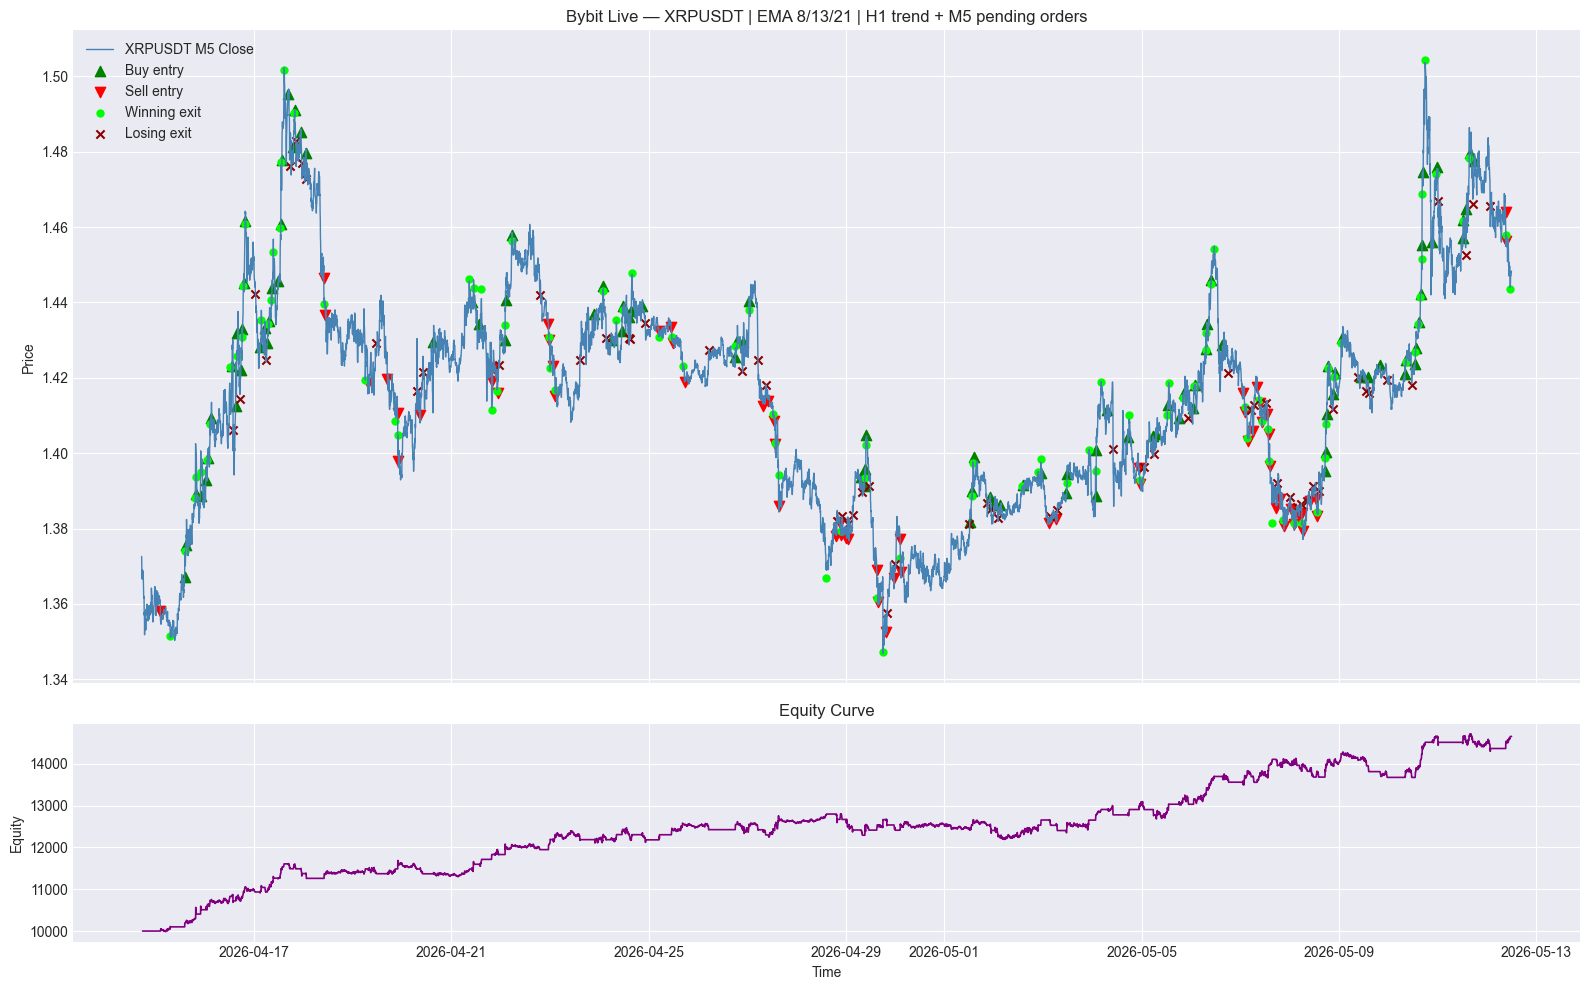

In [50]:
# SECTION 7 — Pilot result chart
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
ax_price, ax_eq = axes

ax_price.plot(m5_ctx.index, m5_ctx["close"],
              label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=1.0)

if not trades_df.empty:
    buys  = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]
    ax_price.scatter(buys["entry_time"],  buys["entry"],  marker="^", color="green",   s=55, label="Buy entry")
    ax_price.scatter(sells["entry_time"], sells["entry"], marker="v", color="red",     s=55, label="Sell entry")
    ax_price.scatter(trades_df[trades_df["pnl"] > 0]["exit_time"],
                     trades_df[trades_df["pnl"] > 0]["exit"],
                     marker="o", color="lime", s=25, label="Winning exit")
    ax_price.scatter(trades_df[trades_df["pnl"] <= 0]["exit_time"],
                     trades_df[trades_df["pnl"] <= 0]["exit"],
                     marker="x", color="darkred", s=35, label="Losing exit")

ax_price.set_title(f"Bybit Live — {SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} | H1 trend + M5 pending orders")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.2)
ax_eq.set_title("Equity Curve")
ax_eq.set_ylabel("Equity")
ax_eq.set_xlabel("Time")

plt.tight_layout()
plt.show()


In [51]:
# SECTION 8 — Save results
RESULT_DIR = Path("./results") / "strategy03_crypto" / SYMBOL / TF_ENTRY
RESULT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(RESULT_DIR / "merics.csv", index=False)

if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time","exit_time","side","entry","sl","tp","exit",
        "qty","pnl","balance_after","result","exit_minus_entry","cumulative_pnl"
    ]).to_csv(RESULT_DIR / "trades.csv", index=False)
else:
    trades_df.to_csv(RESULT_DIR / "trades.csv", index=False)

print(f"Saved -> {RESULT_DIR}")


Saved -> results\strategy03_crypto\XRPUSDT\M5


## Notes

- **Live data**: This notebook fetches from Bybit on every run, so results may differ from the CSV-cached version (`03_strategy03_crypto.ipynb`) when new candles arrive.
- **Reproducibility**: For reproducible results, use `03_strategy03_crypto.ipynb` with a fixed CSV snapshot.
- **Strategy parity**: EMA math, trend logic, signal generation, and risk formula are identical — only data source changed.
- **Symbol mapping**: MT5 `BTCUSD` → Bybit `BTCUSDT`. Set `SYMBOL` accordingly.
